Data exploration.

In [2]:
from SQLoader import load_data_to_db, db_path
import sqlite3

load_data_to_db()

conn = sqlite3.connect(db_path)

Loading tables...
Tables loaded.


Basic data retrieval


In [ ]:
%pip install matplotlib

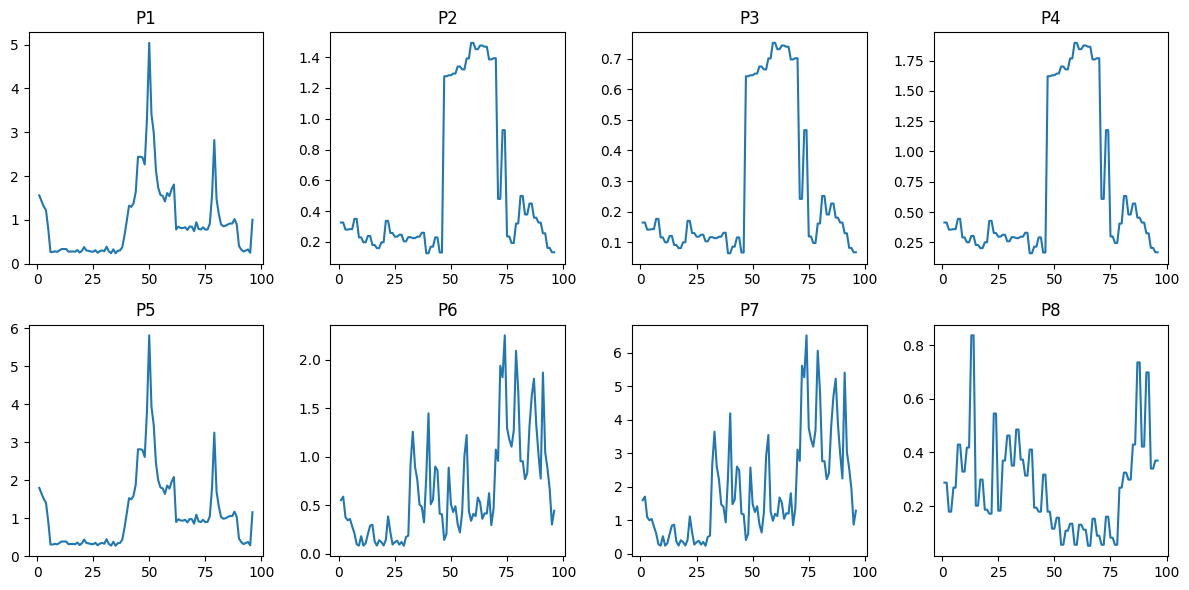

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,4, figsize=(12,6))
for i in range(8):
    df = pd.read_sql(
        f"SELECT period, load_kW FROM load WHERE player_id={i+1}",
        conn
    )
    ax[i//4][i%4].plot(df.period, df.load_kW)
    ax[i//4][i%4].set_title(f"P{i+1}")

plt.tight_layout()
plt.show()



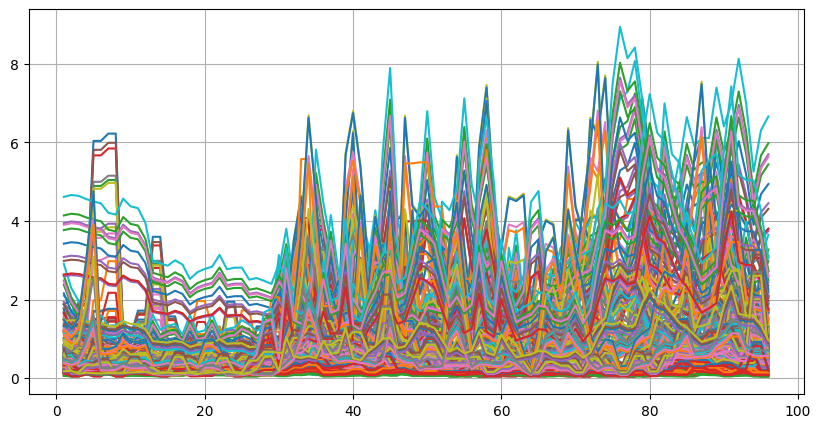

In [5]:
plt.figure(figsize=(10,5))

for i in range(1,250):
    df = pd.read_sql(
        f"SELECT period, load_kW FROM load WHERE player_id={i}",
        conn
    )
    plt.plot(df.period, df.load_kW, label=f"P{i}")

plt.grid(True)
plt.show()


Ok schauen wir mal was wir zu player 1 rausfinden.

<Axes: xlabel='period'>

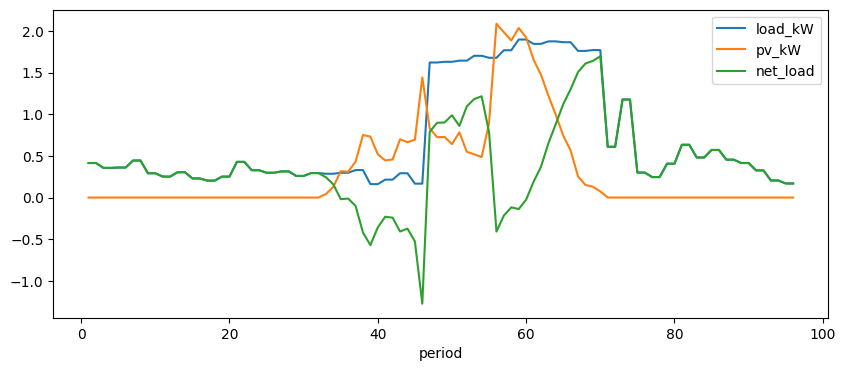

In [6]:
df = pd.read_sql("""
SELECT l.period, l.load_kW, p.pv_kW,
       (l.load_kW - p.pv_kW) AS net_load
FROM load l
JOIN pv p USING(player_id, period)
WHERE l.player_id = 4
""", conn)

df.plot(x="period", y=["load_kW","pv_kW","net_load"], figsize=(10,4))
